In [2]:
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pymannkendall as mk
from pathlib import Path

root = Path('.')

vars = ['t2m', 'ssr', 'sf', 'rf']
var_names = {'t2m': 'Temperature \nanomaly (°C)', 
             'sf':'Snowfall \nanomaly (mm)', 
             'rf':'Rainfall \nanomaly (mm)', 
             'ssr': 'Solar radiation \nanomaly (W m⁻²)'}

In [3]:
# Calculate long-term trends in lake ice phenology for each lake

lake_info = pd.read_csv(root / 'Lake_info.csv', index_col=0)
iceons_long = pd.read_csv(root / 'iceons_long.csv', index_col=0)
iceoffs_long = pd.read_csv(root / 'iceoffs_long.csv', index_col=0)
iceds_long = pd.read_csv(root / 'iceds_long.csv', index_col=0)

result = lake_info.copy()

def calcu_mk(data, lip, result):
    for lake in data.columns:
        mk_ = mk.trend_free_pre_whitening_modification_test(data[lake])
        result.loc[lake, lip + '_slope'] = mk_.slope
        result.loc[lake, lip + '_p'] = mk_.p
    return result

result = calcu_mk(iceons_long, 'iceon', result)
result = calcu_mk(iceoffs_long, 'iceoff', result)
result = calcu_mk(iceds_long, 'iced', result)

result.to_csv(root / 'long_term_trend.csv')

In [ ]:
# Fit detrended OLS models and calculate the relative importance of AR-associated variables for long-term records

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from dominance_analysis import Dominance
from scipy.signal import detrend

lake_info = pd.read_csv(root / 'Lake_info.csv', index_col=0)
iceons_long = pd.read_csv(root / 'iceons_long.csv', index_col=0)
iceoffs_long = pd.read_csv(root / 'iceoffs_long.csv', index_col=0)
iceds_long = pd.read_csv(root / 'iceds_long.csv', index_col=0)

result = lake_info.copy()

def calcu_ols(data, season, result, lip):
    t2ms = pd.read_csv(root / f'AR_related_t2m_anom_{season}.csv', index_col=0)
    ssrs = pd.read_csv(root / f'AR_related_ssr_anom_{season}.csv', index_col=0)
    sfs = pd.read_csv(root / f'AR_related_sf_anom_{season}.csv', index_col=0)
    rfs = pd.read_csv(root / f'AR_related_rf_anom_{season}.csv', index_col=0)
    
    for lake in data.columns:
        data1 = pd.concat([data[lake], t2ms[lake], ssrs[lake], sfs[lake], rfs[lake]], axis=1)
        data1.columns = ['lip', 't2m', 'ssr', 'sf', 'rf']
        data1.dropna(inplace=True)
        
        features = ['t2m', 'ssr', 'sf', 'rf']

        X_dt = data1[features].apply(lambda col: detrend(col.values), axis=0)
        y_dt = detrend(data1['lip'].values)
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_dt)
        
        X_scaled = sm.add_constant(X_scaled)
        model = sm.OLS(y_dt, X_scaled).fit()
        
        result.loc[lake, '%s_model_r2' % lip] = model.rsquared
        result.loc[lake, '%s_model_fp' % lip] = model.f_pvalue
        
        for ii, ff in enumerate(features):
            result.loc[lake, '%s_%s_coef' % (lip, ff)] = model.params[ii + 1]
            result.loc[lake, '%s_%s_ffp' % (lip, ff)] = model.pvalues[ii + 1]
        
        data1_dt = data1.copy()
        data1_dt[features] = X_dt
        data1_dt['lip'] = y_dt
        
        data1_dt[features] = scaler.fit_transform(data1_dt[features])
        
        dominance_regression = Dominance(data=data1_dt, target='lip', objective=1)
        inc_rsquare = dominance_regression.incremental_rsquare()
        general_dominance = dominance_regression.dominance_stats()
        
        for ii, ff in enumerate(features):
            result.loc[lake, '%s_%s_dominance' % (lip, ff)] = general_dominance.loc[ff, 'Total Dominance']
            result.loc[lake, '%s_%s_contribution' % (lip, ff)] = general_dominance.loc[ff, 'Percentage Relative Importance']
    
    return result

result = calcu_ols(iceons_long, 'AutWin', result, 'iceon')
result = calcu_ols(iceoffs_long, 'SprSum', result, 'iceoff')
result = calcu_ols(iceds_long, 'AllYear', result, 'iced')

result.to_csv(root / 'individual_lake_ols_long_detrend.csv')

In [ ]:
# Fit detrended OLS models and calculate the relative importance of AR-associated variables for short-term records

lake_info = pd.read_csv(root / 'Lake_info.csv', index_col=0)
iceons_short = pd.read_csv(root / 'iceons_short.csv', index_col=0)
iceoffs_short = pd.read_csv(root / 'iceoffs_short.csv', index_col=0)
iceds_short = pd.read_csv(root / 'iceds_short.csv', index_col=0)

result = lake_info.copy()

def calcu_ols(data, season, result, lip):
    t2ms = pd.read_csv(root / f'AR_related_t2m_anom_{season}.csv', index_col=0)
    ssrs = pd.read_csv(root / f'AR_related_ssr_anom_{season}.csv', index_col=0)
    sfs = pd.read_csv(root / f'AR_related_sf_anom_{season}.csv', index_col=0)
    rfs = pd.read_csv(root / f'AR_related_rf_anom_{season}.csv', index_col=0)
    
    for lake in data.columns:
        data1 = pd.concat([data[lake], t2ms[lake], ssrs[lake], sfs[lake], rfs[lake]], axis=1)
        data1.columns = ['lip', 't2m', 'ssr', 'sf', 'rf']
        data1.dropna(inplace=True)
        
        features = ['t2m', 'ssr', 'sf', 'rf']

        X_dt = data1[features].apply(lambda col: detrend(col.values), axis=0)
        y_dt = detrend(data1['lip'].values)
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_dt)
        
        X_scaled = sm.add_constant(X_scaled)
        model = sm.OLS(y_dt, X_scaled).fit()
        
        result.loc[lake, '%s_model_r2' % lip] = model.rsquared
        result.loc[lake, '%s_model_fp' % lip] = model.f_pvalue
        
        for ii, ff in enumerate(features):
            result.loc[lake, '%s_%s_coef' % (lip, ff)] = model.params[ii + 1]
            result.loc[lake, '%s_%s_ffp' % (lip, ff)] = model.pvalues[ii + 1]
        
        data1_dt = data1.copy()
        data1_dt[features] = X_dt
        data1_dt['lip'] = y_dt
        
        data1_dt[features] = scaler.fit_transform(data1_dt[features])
        
        dominance_regression = Dominance(data=data1_dt, target='lip', objective=1)
        inc_rsquare = dominance_regression.incremental_rsquare()
        general_dominance = dominance_regression.dominance_stats()
        
        for ii, ff in enumerate(features):
            result.loc[lake, '%s_%s_dominance' % (lip, ff)] = general_dominance.loc[ff, 'Total Dominance']
            result.loc[lake, '%s_%s_contribution' % (lip, ff)] = general_dominance.loc[ff, 'Percentage Relative Importance']
    
    return result

result = calcu_ols(iceons_short, 'AutWin', result, 'iceon')
result = calcu_ols(iceoffs_short, 'SprSum', result, 'iceoff')
result = calcu_ols(iceds_short, 'AllYear', result, 'iced')

result.to_csv(root / 'individual_lake_ols_short_detrend.csv')

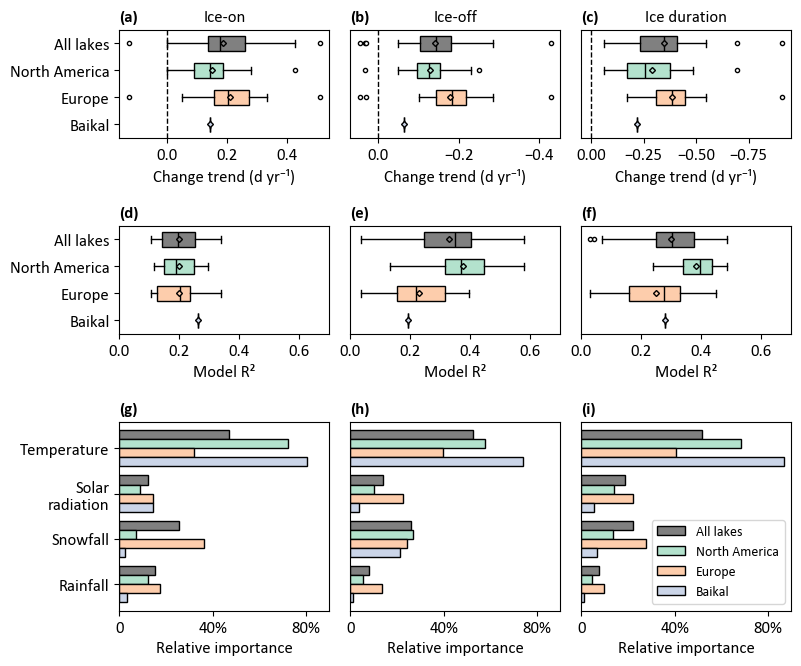

In [5]:
# Draw Figure 3

from matplotlib.patches import Patch

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(8, 6.6), subplot_kw={'projection': None}, gridspec_kw={"height_ratios" : [0.4, 0.4, 0.7]})
axes = axs.ravel()

for ii in range(9):
    axes[ii].set_title('(%s)' % string.ascii_lowercase[ii], fontsize=12, fontweight='bold', loc='left')

    
axes[0].text(0.5, 1.05, 'Ice-on', transform=axes[0].transAxes, ha='center', va='bottom')
axes[1].text(0.5, 1.05, 'Ice-off', transform=axes[1].transAxes, ha='center', va='bottom')
axes[2].text(0.5, 1.05, 'Ice duration', transform=axes[2].transAxes, ha='center', va='bottom')

cmap = plt.cm.Pastel2
colors = ['grey', cmap(0), cmap(1), cmap(2)]  
    
trends = pd.read_csv(root / 'long_term_trend.csv', index_col=0)
lips = ['iceon', 'iceoff', 'iced']

for ii in range(3):
    lip = lips[ii]
    trends1 = trends.dropna(subset=[lip + '_p'])
    box_data = [trends1[lip + '_slope'],
                trends1.loc[trends1['Continent']=='North America', lip + '_slope'],
                trends1.loc[trends1['Continent']=='Europe', lip + '_slope'].drop(['NG1']),
                trends1.loc['NG1', lip + '_slope']]
    
    bp = axes[ii].boxplot(box_data, positions=[3, 2, 1, 0], widths=0.55, vert=False,
                    patch_artist=True, showmeans=True,
                    medianprops=dict(color='k', linewidth=1),
                    flierprops=dict(marker='o', markerfacecolor='w', markersize=3),
                    meanprops=dict(marker='D', markeredgecolor='k', markersize=3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    for patch, color in zip(bp['means'], colors):
        patch.set_markerfacecolor(color)
        
    axes[ii].set_xlabel('Change trend (d yr⁻¹)')
    axes[ii].axvline(x=0, linestyle='--', color='k', linewidth=1)
    
    if ii in [1, 2]:
        axes[ii].invert_xaxis()

    
data = pd.read_csv(root / 'individual_lake_ols_long_detrend.csv', index_col=0)
lake_ct = pd.read_csv(root / "lakes_with_continent.csv")
data = data.merge(
    lake_ct[['LAKEID', 'CONTINENT']], 
    on='LAKEID',
    how='left'  
)

def draw_box(ax, lip):
    box_data = [data[lip + '_model_r2'].dropna(),
                data.loc[data['CONTINENT']=='North America', lip + '_model_r2'].dropna(),
                data.loc[data['CONTINENT']=='Europe', lip + '_model_r2'].dropna(),
                data.loc[data['CONTINENT']=='Asia', lip + '_model_r2'].dropna()]
    
    bp = ax.boxplot(box_data, positions=[3, 2, 1, 0], widths=0.55, vert=False,
                    patch_artist=True, showmeans=True,
                    medianprops=dict(color='k', linewidth=1),
                    flierprops=dict(marker='o', markerfacecolor='w', markersize=3),
                    meanprops=dict(marker='D', markeredgecolor='k', markersize=3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    for patch, color in zip(bp['means'], colors):
        patch.set_markerfacecolor(color)
    
    ax.set_xlim((0, 0.7))
    ax.set_xlabel("Model R²")
    return 


def draw_bar(ax, lip):
    for var, loc in zip(['t2m', 'ssr', 'sf', 'rf'], [3, 2, 1, 0]):
        bar_data = [np.mean(data['%s_%s_contribution' % (lip, var)].dropna()),
                    np.mean(data.loc[data['CONTINENT']=='North America', '%s_%s_contribution' % (lip, var)].dropna()),
                    np.mean(data.loc[data['CONTINENT']=='Europe', '%s_%s_contribution' % (lip, var)].dropna()),
                    np.mean(data.loc[data['CONTINENT']=='Asia', '%s_%s_contribution' % (lip, var)].dropna()),]

        ax.barh(loc + np.array([0.3, 0.1, -0.1, -0.3]), bar_data, color=colors, edgecolor=['k'], height=0.2)

    ax.set_xlim((0, 90))
    ax.set_xticks([0, 40, 80], [0, '40%', '80%'])
    ax.set_xlabel('Relative importance')


draw_box(axes[3], 'iceon')
draw_box(axes[4], 'iceoff')
draw_box(axes[5], 'iced')

draw_bar(axes[6], 'iceon')
draw_bar(axes[7], 'iceoff')
draw_bar(axes[8], 'iced')

for ii in [1, 2, 4, 5, 7, 8]:
    axes[ii].set_yticks([])

axes[0].set_yticks([3, 2, 1, 0], ['All lakes', 'North America', 'Europe', 'Baikal']) 
axes[3].set_yticks([3, 2, 1, 0], ['All lakes', 'North America', 'Europe', 'Baikal'])
axes[6].set_yticks([3, 2, 1, 0], ['Temperature', 'Solar\nradiation', 'Snowfall', 'Rainfall'])

legend_elements = [Patch(facecolor=c, edgecolor='k', label=l) for c, l in zip(colors, ['All lakes', 'North America', 'Europe', 'Baikal'])]
axes[8].legend(handles=legend_elements, fontsize='small')

fig.subplots_adjust(bottom=0.08, top=0.96, left=0.15, right=0.99, wspace=0.1, hspace=0.65)
plt.show()

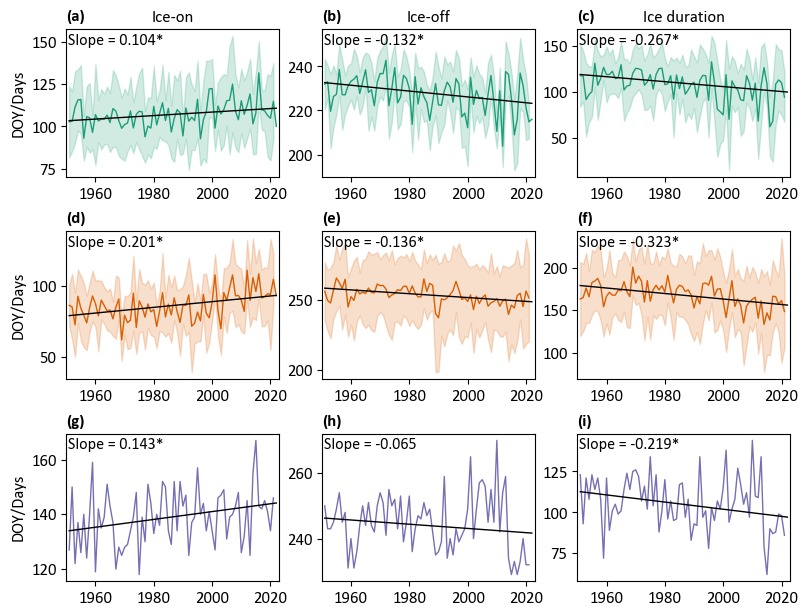

In [7]:
# Draw Figure S5

cols = ["Ice-on", "Ice-off", "Ice duration", ]

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(8, 6))
axes = axs.ravel()

cmap = plt.cm.Dark2

colors = {'NA': cmap(0), 'EU': cmap(1), 'BK': cmap(2)}

def draw_trend(ax, x, y):
    result = mk.trend_free_pre_whitening_modification_test(y)
    slope = result.slope
    intercept = result.intercept
    trend_line = slope * (x-x[0]) + intercept
    p = result.p

    if p < 0.05:
        stars = "*"
    else:
        stars = ""
    
    ax.plot(x, trend_line, 'k-', lw=1)
    ax.text(0.01, 0.97, f"Slope = {slope:.3f}{stars}", va='top', ha='left', transform=ax.transAxes, fontsize=11.5)
    return


def draw_annual_series(df, ii, region):
    mean_series2 = df.mean(axis=1)
    axes[ii].plot(df.index, mean_series2, color=colors[region], zorder=1, linewidth=1)

    std_series2 = df.std(axis=1)
    upper2 = mean_series2 + std_series2
    lower2 = mean_series2 - std_series2
    axes[ii].fill_between(df.index, lower2, upper2, color=colors[region], alpha=0.2, zorder=1)
    
    draw_trend(axes[ii], mean_series2.index, mean_series2)
    
    axes[ii].set_xlim([1950, 2023])
    return
    

def draw_region(region, ii0):   
    iceons = pd.read_csv(root / f'Iceon_long_data_{region}.csv', index_col=0)
    iceoffs = pd.read_csv(root / f'Iceoff_long_data_{region}.csv', index_col=0)
    durations = pd.read_csv(root / f'Iced_long_data_{region}.csv', index_col=0)
    
    for df, ii in zip([iceons, iceoffs, durations], range(3)):
        draw_annual_series(df, ii+ii0, region)
    
    return


def draw_BK(ii0):
    iceons = pd.read_csv(root / 'iceons_long.csv', index_col=0)
    iceoffs = pd.read_csv(root / 'iceoffs_long.csv', index_col=0)
    iceds = pd.read_csv(root / 'iceds_long.csv', index_col=0)
    
    axes[0+ii0].plot(iceons.index, iceons['NG1'], color=colors['BK'], zorder=1, linewidth=1)
    axes[1+ii0].plot(iceoffs.index, iceoffs['NG1'], color=colors['BK'], zorder=1, linewidth=1)
    axes[2+ii0].plot(iceds.index, iceds['NG1'], color=colors['BK'], zorder=1, linewidth=1)
    
    for ii, data in zip(range(3), [iceons, iceoffs, iceds]):
    
        draw_trend(axes[ii0+ii], data.index, data['NG1'])
    
    return

draw_region('NA', 0)
draw_region('EU', 3)
draw_BK(6)

for ii in range(9):
    axes[ii].set_xlim([1950, 2023])
    axes[ii].set_title('(%s)' % string.ascii_lowercase[ii], fontsize=12, fontweight='bold', loc='left')
for ii in [0, 3, 6]:
    axes[ii].set_ylabel('DOY/Days')

axes[0].text(0.5, 1.03, 'Ice-on', transform=axes[0].transAxes, ha='center', va='bottom', fontsize=12)
axes[1].text(0.5, 1.03, 'Ice-off', transform=axes[1].transAxes, ha='center', va='bottom', fontsize=12)
axes[2].text(0.5, 1.03, 'Ice duration', transform=axes[2].transAxes, ha='center', va='bottom', fontsize=12)

fig.subplots_adjust(bottom=0.04, top=0.96, left=0.08, right=0.985, hspace=0.37)
plt.show()

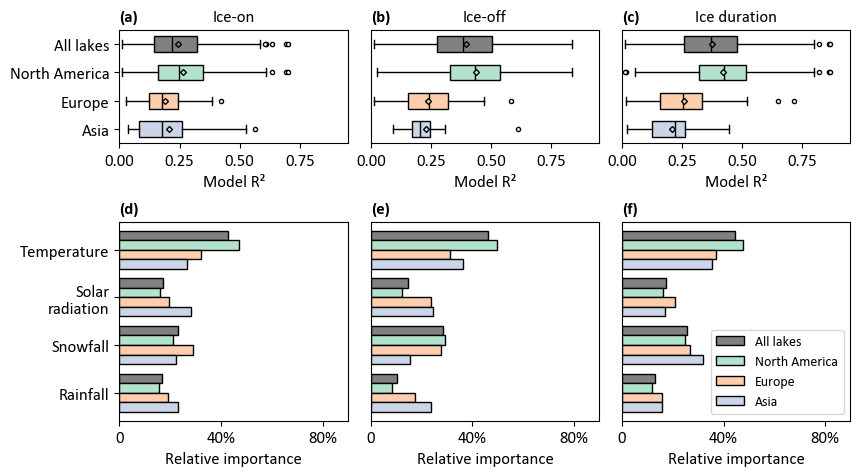

In [8]:
# Draw Figure S6

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8.5, 4.6), subplot_kw={'projection': None}, gridspec_kw={"height_ratios" : [0.4, 0.7]})
axes = axs.ravel()

for ii in range(6):
    axes[ii].set_title('(%s)' % string.ascii_lowercase[ii], fontsize=12, fontweight='bold', loc='left')

    
axes[0].text(0.5, 1.05, 'Ice-on', transform=axes[0].transAxes, ha='center', va='bottom')
axes[1].text(0.5, 1.05, 'Ice-off', transform=axes[1].transAxes, ha='center', va='bottom')
axes[2].text(0.5, 1.05, 'Ice duration', transform=axes[2].transAxes, ha='center', va='bottom')

cmap = plt.cm.Pastel2
colors = ['grey', cmap(0), cmap(1), cmap(2)] 

lips = ['iceon', 'iceoff', 'iced']
    
data = pd.read_csv(root / 'individual_lake_ols_short_detrend.csv', index_col=0)
lake_ct = pd.read_csv(root / 'lakes_with_continent.csv')
data = data.merge(
    lake_ct[['LAKEID', 'CONTINENT']], 
    on='LAKEID',
    how='left'  
)

def draw_box(ax, lip):
    box_data = [data[lip + '_model_r2'].dropna(),
                data.loc[data['CONTINENT']=='North America', lip + '_model_r2'].dropna(),
                data.loc[data['CONTINENT']=='Europe', lip + '_model_r2'].dropna(),
                data.loc[data['CONTINENT']=='Asia', lip + '_model_r2'].dropna()]
    
    bp = ax.boxplot(box_data, positions=[3, 2, 1, 0], widths=0.55, vert=False,
                    patch_artist=True, showmeans=True,
                    medianprops=dict(color='k', linewidth=1),
                    flierprops=dict(marker='o', markerfacecolor='w', markersize=3),
                    meanprops=dict(marker='D', markeredgecolor='k', markersize=3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    for patch, color in zip(bp['means'], colors):
        patch.set_markerfacecolor(color)
    
    ax.set_xlim((0, 0.95))
    ax.set_xlabel("Model R²")
    return 


def draw_bar(ax, lip):
    for var, loc in zip(['t2m', 'ssr', 'sf', 'rf'], [3, 2, 1, 0]):
        bar_data = [np.mean(data['%s_%s_contribution' % (lip, var)].dropna()),
                    np.mean(data.loc[data['CONTINENT']=='North America', '%s_%s_contribution' % (lip, var)].dropna()),
                    np.mean(data.loc[data['CONTINENT']=='Europe', '%s_%s_contribution' % (lip, var)].dropna()),
                    np.mean(data.loc[data['CONTINENT']=='Asia', '%s_%s_contribution' % (lip, var)].dropna()),]

        ax.barh(loc + np.array([0.3, 0.1, -0.1, -0.3]), bar_data, color=colors, edgecolor=['k'], height=0.2)
    
    ax.set_xlim((0, 90))
    ax.set_xticks([0, 40, 80], [0, '40%', '80%'])
    ax.set_xlabel('Relative importance')


draw_box(axes[0], 'iceon')
draw_box(axes[1], 'iceoff')
draw_box(axes[2], 'iced')

draw_bar(axes[3], 'iceon')
draw_bar(axes[4], 'iceoff')
draw_bar(axes[5], 'iced')

for ii in [1, 2, 4, 5]:
    axes[ii].set_yticks([])

axes[0].set_yticks([3, 2, 1, 0], ['All lakes', 'North America', 'Europe', 'Asia'])
axes[3].set_yticks([3, 2, 1, 0], ['Temperature', 'Solar\nradiation', 'Snowfall', 'Rainfall'])

legend_elements = [Patch(facecolor=c, edgecolor='k', label=l) for c, l in zip(colors, ['All lakes', 'North America', 'Europe', 'Asia'])]
axes[5].legend(handles=legend_elements, fontsize=10)

fig.subplots_adjust(bottom=0.1, top=0.95, left=0.13, right=0.99, wspace=0.1, hspace=0.5)
plt.show()

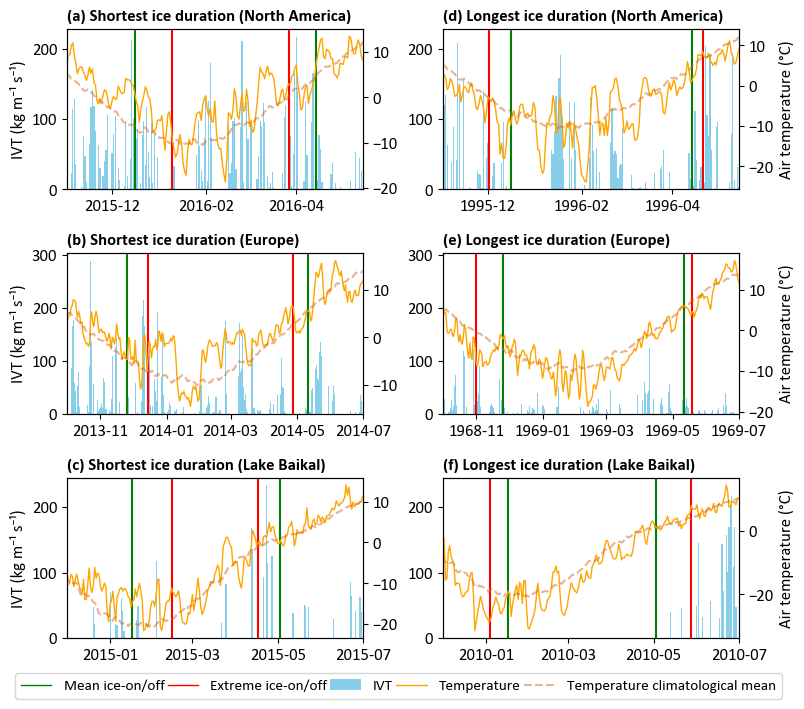

In [12]:
# Draw Figure S7

import datetime
import matplotlib.dates as mdates

mpl.rcParams.update({'font.size': 12, 'font.sans-serif': 'Calibri'})
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(8, 7), )
axes = axs.ravel()


def draw_NA():
    extreme_years = {'shortest': 2016,
                     'longest': 1996,}
    
    iceons = pd.read_csv(root / 'Iceon_long_data_NA.csv', index_col=0)
    iceoffs = pd.read_csv(root / 'Iceoff_long_data_NA.csv', index_col=0)
    sites = list(set(iceons.columns.tolist() + iceoffs.columns.tolist()))
    
    ivts = pd.read_csv(root / 'IVT_extraction_daily.csv', index_col=0)[sites]
    ivts.index = pd.to_datetime(ivts.index)
    t2ms = pd.read_csv(root / 't2m_extraction.csv', index_col=0)[sites]
    t2ms.index = pd.to_datetime(t2ms.index)
    t2ms_clim = pd.read_csv(root / 't2m_clim_mean.csv', index_col=0)[sites]
    t2ms_clim.index = pd.to_datetime(t2ms_clim.index)
    
    def draw_year(ax, year, tt=False):
        iceon_date = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceons.mean(axis=1)[year])
        iceon_mean = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceons.mean(axis=1).mean())
        
        ax.axvline(x=iceon_date, color='red', linestyle='-', linewidth=1.5, zorder=100)
        ax.axvline(x=iceon_mean, color='green', linestyle='-', linewidth=1.5, zorder=100)
     
        iceoff_date = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceoffs.mean(axis=1)[year])
        iceoff_mean = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceoffs.mean(axis=1).mean())
        
        ax.axvline(x=iceoff_date, color='red', linestyle='-', linewidth=1.5, zorder=100)
        ax.axvline(x=iceoff_mean, color='green', linestyle='-', linewidth=1.5, zorder=100)
        
        year_period = pd.date_range(str(year-1) + '-11-01', str(year) + '-05-15')
        ax.set_xlim(year_period[0], year_period[-1])
        
        ivts_year = ivts.loc[year_period]
        ivts_mean = ivts_year.mean(axis=1)
        ax.bar(year_period, ivts_mean, width=0.8, color="skyblue")
        
        axt = ax.twinx()
        t2ms_year = t2ms.loc[year_period]
        t2ms_mean = t2ms_year.mean(axis=1) - 273.15
        axt.plot(year_period, t2ms_mean, color="orange", linewidth=1, zorder=1)
        
        ts = year_period[~((year_period.month == 2) & (year_period.day == 29))]
        t2ms_clim_year = t2ms_clim.loc[ts]
        t2ms_clim_mean = t2ms_clim_year.mean(axis=1) - 273.15
        axt.plot(ts, t2ms_clim_mean, color="#D2691E", linewidth=1.5, zorder=1, linestyle='--', alpha=0.5)
        
        if tt:
            axt.set_ylabel('Air temperature (°C)')
        return 
    
    draw_year(axes[0], extreme_years['shortest'])
    draw_year(axes[1], extreme_years['longest'], True)

    
    ax_max = np.max([axes[ii].get_ylim()[1] for ii in [0, 1]])
    for ii in [0, 1]:
        axes[ii].set_ylim([0, ax_max])
        axes[ii].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].set_ylabel('IVT (kg m⁻¹ s⁻¹)')
    return


def draw_EU():
    extreme_years = {'shortest': 2014,
                     'longest': 1969,}
    
    iceons = pd.read_csv(root / 'Iceon_long_data_EU.csv', index_col=0)
    iceoffs = pd.read_csv(root / 'Iceoff_long_data_EU.csv', index_col=0)
    sites = list(set(iceons.columns.tolist() + iceoffs.columns.tolist()))
    
    ivts = pd.read_csv(root / 'IVT_extraction_daily.csv', index_col=0)[sites]
    ivts.index = pd.to_datetime(ivts.index)
    t2ms = pd.read_csv(root / 't2m_extraction.csv', index_col=0)[sites]
    t2ms.index = pd.to_datetime(t2ms.index)
    t2ms_clim = pd.read_csv(root / 't2m_clim_mean.csv', index_col=0)[sites]
    t2ms_clim.index = pd.to_datetime(t2ms_clim.index)
    
    def draw_year(ax, year, tt=False):
        iceon_date = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceons.mean(axis=1)[year])
        iceon_mean = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceons.mean(axis=1).mean())
        
        ax.axvline(x=iceon_date, color='red', linestyle='-', linewidth=1.5, zorder=101)
        ax.axvline(x=iceon_mean, color='green', linestyle='-', linewidth=1.5, zorder=100)
     
        iceoff_date = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceoffs.mean(axis=1)[year])
        iceoff_mean = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceoffs.mean(axis=1).mean())
        
        ax.axvline(x=iceoff_date, color='red', linestyle='-', linewidth=1.5, zorder=101)
        ax.axvline(x=iceoff_mean, color='green', linestyle='-', linewidth=1.5, zorder=100)
        
        year_period = pd.date_range(str(year-1) + '-10-01', str(year) + '-07-01')
        ax.set_xlim(year_period[0], year_period[-1])
        
        ivts_year = ivts.loc[year_period]
        ivts_mean = ivts_year.mean(axis=1)
        ax.bar(year_period, ivts_mean, width=0.8, color="skyblue")
        
        axt = ax.twinx()
        t2ms_year = t2ms.loc[year_period]
        t2ms_mean = t2ms_year.mean(axis=1) - 273.15
        axt.plot(year_period, t2ms_mean, color="orange", linewidth=1, zorder=1)
        
        ts = year_period[~((year_period.month == 2) & (year_period.day == 29))]
        t2ms_clim_year = t2ms_clim.loc[ts]
        t2ms_clim_mean = t2ms_clim_year.mean(axis=1) - 273.15
        axt.plot(ts, t2ms_clim_mean, color="#D2691E", linewidth=1.5, zorder=1, linestyle='--', alpha=0.5)
        
        if tt:
            axt.set_ylabel('Air temperature (°C)')
        return 
        
    draw_year(axes[2], extreme_years['shortest'])
    draw_year(axes[3], extreme_years['longest'], True)
    
    ax_max = np.max([axes[ii].get_ylim()[1] for ii in [2, 3]])
    for ii in [2, 3]:
        axes[ii].set_ylim([0, ax_max])
        axes[ii].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[2].set_ylabel('IVT (kg m⁻¹ s⁻¹)')
    return


def draw_BK():
    extreme_years = {'shortest': 2015,
                     'longest': 2010,}
    
    iceons = pd.read_csv(root / 'iceons_long.csv', index_col=0)['NG1']
    iceoffs = pd.read_csv(root / 'iceoffs_long.csv', index_col=0)['NG1']
    
    ivts = pd.read_csv(root / 'IVT_extraction_daily.csv', index_col=0)['NG1']
    ivts.index = pd.to_datetime(ivts.index)
    t2ms = pd.read_csv(root / 't2m_extraction.csv', index_col=0)['NG1']
    t2ms.index = pd.to_datetime(t2ms.index)
    t2ms_clim = pd.read_csv(root / 't2m_clim_mean.csv', index_col=0)['NG1']
    t2ms_clim.index = pd.to_datetime(t2ms_clim.index)
    
    def draw_year(ax, year, tt=False):
        iceon_date = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceons[year])
        iceon_mean = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceons.mean())
        
        ax.axvline(x=iceon_date, color='red', linestyle='-', linewidth=1.5, zorder=101)
        ax.axvline(x=iceon_mean, color='green', linestyle='-', linewidth=1.5, zorder=100)
     
        iceoff_date = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceoffs[year])
        iceoff_mean = datetime.datetime(year-1, 8, 31) + datetime.timedelta(days=iceoffs.mean())
        
        ax.axvline(x=iceoff_date, color='red', linestyle='-', linewidth=1.5, zorder=101)
        ax.axvline(x=iceoff_mean, color='green', linestyle='-', linewidth=1.5, zorder=100)
        
        year_period = pd.date_range(str(year-1) + '-12-01', str(year) + '-07-01')
        ax.set_xlim(year_period[0], year_period[-1])
        
        ivts_year = ivts.loc[year_period]
        ivts_mean = ivts_year
        ax.bar(year_period, ivts_mean, width=0.8, color="skyblue")
        
        axt = ax.twinx()
        t2ms_year = t2ms.loc[year_period]
        t2ms_mean = t2ms_year - 273.15
        axt.plot(year_period, t2ms_mean, color="orange", linewidth=1, zorder=1)
        
        ts = year_period[~((year_period.month == 2) & (year_period.day == 29))]
        t2ms_clim_year = t2ms_clim.loc[ts]
        t2ms_clim_mean = t2ms_clim_year - 273.15
        axt.plot(ts, t2ms_clim_mean, color="#D2691E", linewidth=1.5, zorder=1, linestyle='--', alpha=0.5)
        
        if tt:
            axt.set_ylabel('Air temperature (°C)')
        return 
        
    draw_year(axes[4], extreme_years['shortest'])
    draw_year(axes[5], extreme_years['longest'], True)
    
    ax_max = np.max([axes[ii].get_ylim()[1] for ii in [4, 5]])
    for ii in [4, 5]:
        axes[ii].set_ylim([0, ax_max])
        axes[ii].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[4].set_ylabel('IVT (kg m⁻¹ s⁻¹)')
    return

draw_NA()
draw_EU()
draw_BK()

axes[0].set_title('(a) Shortest ice duration (North America)', loc='left', fontweight='bold', fontsize=12)
axes[1].set_title('(d) Longest ice duration (North America)', loc='left', fontweight='bold', fontsize=12)
axes[2].set_title('(b) Shortest ice duration (Europe)', loc='left', fontweight='bold', fontsize=12)
axes[3].set_title('(e) Longest ice duration (Europe)', loc='left', fontweight='bold', fontsize=12)
axes[4].set_title('(c) Shortest ice duration (Lake Baikal)', loc='left', fontweight='bold', fontsize=12)
axes[5].set_title('(f) Longest ice duration (Lake Baikal)', loc='left', fontweight='bold', fontsize=12)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

line_handle1 = Line2D([0], [0], color='green', lw=1)
line_handle2 = Line2D([0], [0], color='red', lw=1)  
bar_handle = Patch(facecolor='skyblue',)
line_handle3 = Line2D([0], [0], color='orange', lw=1) 
line_handle4 = Line2D([0], [0], color='#D2691E', lw=1.5, linestyle='--', alpha=0.5) 

axes[4].legend(handles=[line_handle1, line_handle2, bar_handle, line_handle3, line_handle4], 
               labels=['Mean ice-on/off', 'Extreme ice-on/off', 'IVT', 'Temperature', 'Temperature climatological mean'], 
               bbox_to_anchor=(1.12, -0.3), 
               loc='center', ncol=5, fontsize=11, columnspacing=0.2)


fig.subplots_adjust(bottom=0.09, top=0.96, left=0.08, right=0.92, wspace=0.27, hspace=0.4)
plt.show()